In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
from Python_files import TLM_Test as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM_ensemble as LETLMC
from Python_files import IETLM_ensemble as IETLMC
from Python_files import GETLM as GETLMC


#  We also need to set the precision to be higher as we are working with very small perturbations
torch.set_default_dtype(torch.float64)


In [2]:
# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [3]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)



100%|██████████| 999/999 [00:00<00:00, 10911.83it/s]


In [4]:
# We now need to do this experiment multiple times
# We will do thirty experiments and see which of the GETLM outperforms the IETLM 
# at the 1,2,5, 10, 15 and 20th time steps

In [5]:
# The first step is to wrap the whole code in a function so that we can run it multiple times 
def IETLM_GETLM_COMP(stencil, x_out, Test_pert,steps):
    # The first step to do this is to work out what we want to use as our stencil
    stencil_members_future_CN = [0]
    stencil_members_current_CN = stencil
    stencil_members_past_CN = []
    stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]

    # Now that we have our stencil we can calculate how many ensemble members we need 
    ensemble_size_CN = 2 + len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN)

    # We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
    SD_pert = 10**(-7)

    # We also need to define our test perturbation
    # Test_pert_current = torch.randn(N) * SD_pert
    # Test_pert_past = torch.randn(N) * SD_pert
    # Test_pert = (Test_pert_current, Test_pert_past)


    test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run=  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = steps)
    LETLM_STENCIL_LARGE = [[0],stencil]

    # Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
    GETLMS_1= []
    GETLMS_2= []
    GETLMS_3= []
    GETLMS_4= []

    LETLMS = []

    for i in range(len(Ensemble_final)-2):
        # We start by selecting the ensembles at each time level
        Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
        Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
        X   = Ensemble_final[i]
        k1 = 1 # number of zero eigenvalue eigenvalues
        k2 = 2 # number of zero eigenvalue eigenvalues
        k3 = 3 # number of zero eigenvalue eigenvalues
        k4 = 4 # number of zero eigenvalue eigenvalues

        # We now make the GETLM
        N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k1, plot = False)
        GETLMS_1.append([N_tilde_G, L_tilde_G, K_tilde_G])

        N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k2, plot = False)
        GETLMS_2.append([N_tilde_G, L_tilde_G, K_tilde_G])

        N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k3, plot = False)
        GETLMS_3.append([N_tilde_G, L_tilde_G, K_tilde_G])

        N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k4, plot = False)
        GETLMS_4.append([N_tilde_G, L_tilde_G, K_tilde_G])

        # We will now make the IETLM
        LETLM_temp = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
        LETLMS.append(LETLM_temp)



    # We will now compare the TLMS to the actual data to see 

    # We first set a starting point for the TLMS
    starting_time = 1

    x_values = np.arange(1, N + 1)

    IETLM_norm = []
    GETLM_norm = []


    LETLM_TT_result = []
    GETLM_1_TT_result = []
    GETLM_2_TT_result = []
    GETLM_3_TT_result = []
    GETLM_4_TT_result = []



    # The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
    test_0 = test_final_pert[1+starting_time]
    LETLM_test = test_0


    GETLM_test_future_1 = test_0
    GETLM_test_future_2 = test_0
    GETLM_test_future_3 = test_0
    GETLM_test_future_4 = test_0


    GETLM_test_current_1 = test_final_pert[1+starting_time]
    GETLM_test_current_2 = test_final_pert[1+starting_time]
    GETLM_test_current_3 = test_final_pert[1+starting_time]
    GETLM_test_current_4 = test_final_pert[1+starting_time]

    # getlm_norm = L2_norm(GETLM_test_future, test_0)






    index = 1+starting_time


    LETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )

    GETLM_1_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
    GETLM_2_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
    GETLM_3_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
    GETLM_4_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )





    LETLM_TT_result.append(LETLM_TT)

    GETLM_1_TT_result.append(GETLM_1_TT)
    GETLM_2_TT_result.append(GETLM_2_TT)
    GETLM_3_TT_result.append(GETLM_3_TT)
    GETLM_4_TT_result.append(GETLM_4_TT)





    # plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')

    # plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)

    # plt.plot(x_values, GETLM_test_future_1.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
    # plt.plot(x_values, GETLM_test_future_2.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
    # plt.plot(x_values, GETLM_test_future_3.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
    # plt.plot(x_values, GETLM_test_future_4.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

    # plt.title(f"Ensemble at zero: Prediction vs Actual")
    # plt.xlabel("N")
    # plt.ylabel("Value")
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.show() # This creates a fresh window/plot for each step in the loop

    # We will now go through the steps to see how each of the TLMS goes 
    for i in range(len(test_final_pert)-3):
        index = i+2 + starting_time
        test = test_final_pert[i+2 + starting_time]


        # Ploting the IETLM
        letlm = LETLMS[i+starting_time]
        # print(letlm.shape)
        LETLM_test = letlm @ LETLM_test


        letlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], LETLM_test)
        LETLM_TT_result.append(letlm_tt)


        # IETLM_TT = torch.cat((IETLM_TT, ietlm_tt), dim = 0)



        GETLM_test_past_1 = GETLM_test_current_1
        GETLM_test_current_1 = GETLM_test_future_1

        GETLM_test_past_2 = GETLM_test_current_2
        GETLM_test_current_2 = GETLM_test_future_2

        GETLM_test_past_3 = GETLM_test_current_3
        GETLM_test_current_3 = GETLM_test_future_3

        GETLM_test_past_4 = GETLM_test_current_4
        GETLM_test_current_4 = GETLM_test_future_4

        NL = torch.pinverse(GETLMS_1[i+starting_time][0]) @ GETLMS_1[i+starting_time][1]
        NK = torch.pinverse(GETLMS_1[i+starting_time][0]) @ GETLMS_1[i+starting_time][2]
        GETLM_test_future_1 = NL @ GETLM_test_current_1 + NK @ GETLM_test_past_1

        NL = torch.pinverse(GETLMS_2[i+starting_time][0]) @ GETLMS_2[i+starting_time][1]
        NK = torch.pinverse(GETLMS_2[i+starting_time][0]) @ GETLMS_2[i+starting_time][2]
        GETLM_test_future_2 = NL @ GETLM_test_current_2 + NK @ GETLM_test_past_2
        
        NL = torch.pinverse(GETLMS_3[i+starting_time][0]) @ GETLMS_3[i+starting_time][1]
        NK = torch.pinverse(GETLMS_3[i+starting_time][0]) @ GETLMS_3[i+starting_time][2]
        GETLM_test_future_3 = NL @ GETLM_test_current_3 + NK @ GETLM_test_past_3

        NL = torch.pinverse(GETLMS_4[i+starting_time][0]) @ GETLMS_4[i+starting_time][1]
        NK = torch.pinverse(GETLMS_4[i+starting_time][0]) @ GETLMS_4[i+starting_time][2]
        GETLM_test_future_4 = NL @ GETLM_test_current_4 + NK @ GETLM_test_past_4

        getlm_tt_1 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_1)
        getlm_tt_2 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_2)
        getlm_tt_3 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_3)
        getlm_tt_4 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_4)


        # GETLM_TT = torch.cat((GETLM_TT, getlm_tt), dim = 0)
        GETLM_1_TT_result.append(getlm_tt_1)
        GETLM_2_TT_result.append(getlm_tt_2)
        GETLM_3_TT_result.append(getlm_tt_3)
        GETLM_4_TT_result.append(getlm_tt_4)




        

        # # We now need to calculate the L2 norm

        # letlm_norm = L2_norm(LETLM_test, test)
        # ietlm_norm = L2_norm(IETLM_test, test)
        # getlm_norm = L2_norm(GETLM_test_future, test)
        # print('IETLM norm:', ietlm_norm)
        # print('LETLM norm:', letlm_norm)
        # print('GETLM norm:', getlm_norm)
        # LETLM_norm.append(letlm_norm)
        # IETLM_norm.append(ietlm_norm)
        # GETLM_norm.append(getlm_norm)

        # plt.figure(figsize=(12, 4))  # width=12 inches, height=4 inches
        # # plt.ylim(-0.0015, 0.0015)


        # plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
        # plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='black', linewidth=1)
        # plt.plot(x_values, GETLM_test_future_1.detach().cpu().numpy(), label='Predicted (GETLM 1 eigenvalue)', color='purple', linewidth=1)
        # plt.plot(x_values, GETLM_test_future_2.detach().cpu().numpy(), label='Predicted (GETLM 2 eigenvalues)', color='aqua', linewidth=1)
        # plt.plot(x_values, GETLM_test_future_3.detach().cpu().numpy(), label='Predicted (GETLM 3 eigenvalues)', color='orange', linewidth=1)
        # plt.plot(x_values, GETLM_test_future_4.detach().cpu().numpy(), label='Predicted (GETLM 4 eigenvalues)', color='lime', linewidth=1)



        # plt.title(f"Crank-Nicolson Perturbations after {i+1} time steps: Prediction vs Actual")

        # plt.xlabel("N")
        # plt.ylabel("Value")
        # plt.legend()

        # plt.grid(True, alpha=0.3)
        # plt.show() # This creates a fresh window/plot for each step in the loop
        # plt.clf()
        
        # print('TLM Test GETLM (1):', getlm_tt_1)
        # print('TLM Test GETLM (2):', getlm_tt_2)
        # print('TLM Test GETLM (3):', getlm_tt_3)
        # print('TLM Test GETLM (4):', getlm_tt_4)


        # print('TLM Test IETLM:', ietlm_tt)

        
        # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
        # plt.show()
        # plt.clf()

    return LETLM_TT_result, GETLM_1_TT_result, GETLM_2_TT_result, GETLM_3_TT_result, GETLM_4_TT_result



In [6]:
trials = 30
steps = 20
SD_pert = 10**(-7)
N = 40

results_LETLM = torch.zeros((trials, steps))
results_GETLM_1 = torch.zeros((trials, steps))
results_GETLM_2 = torch.zeros((trials, steps))
results_GETLM_3 = torch.zeros((trials, steps))
results_GETLM_4 = torch.zeros((trials, steps))



Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)

In [23]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)


# We will now define our stencil that we want to use
stencil = [-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5]

for i in tqdm(range(trials)):
    torch.manual_seed(4*i**3)
    Test_pert_current = torch.randn(N) * SD_pert
    torch.manual_seed(4*i**3 + 1)
    Test_pert_past = torch.randn(N) * SD_pert
    Test_pert = (Test_pert_current, Test_pert_past)

    LETLM_TT_result, GETLM_1_TT_result, GETLM_2_TT_result, GETLM_3_TT_result, GETLM_4_TT_result = IETLM_GETLM_COMP(stencil, x_out, Test_pert, steps)
    
    results_LETLM[i,:] = torch.tensor(LETLM_TT_result)
    results_GETLM_1[i,:] = torch.tensor(GETLM_1_TT_result)
    results_GETLM_2[i,:] = torch.tensor(GETLM_2_TT_result)
    results_GETLM_3[i,:] = torch.tensor(GETLM_3_TT_result)
    results_GETLM_4[i,:] = torch.tensor(GETLM_4_TT_result)


100%|██████████| 30/30 [00:15<00:00,  1.95it/s]


In [24]:
# We can now take the mean of the results 
LETLM_mean = results_LETLM.mean(dim=0)
GETLM_mean_1 = results_GETLM_1.mean(dim=0)
GETLM_mean_2 = results_GETLM_2.mean(dim=0)
GETLM_mean_3 = results_GETLM_3.mean(dim=0)
GETLM_mean_4 = results_GETLM_4.mean(dim=0)



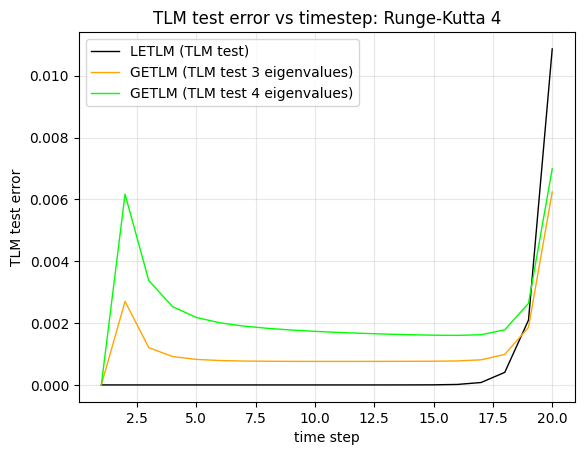

<Figure size 640x480 with 0 Axes>

In [30]:
x_values_norm = np.arange(1,steps+1)


plt.plot(x_values_norm, LETLM_mean, label='LETLM (TLM test)', color='black', linewidth=1)
# plt.plot(x_values_norm, GETLM_mean_1, label='GETLM (TLM test 1 eigenvalue)', color='purple', linewidth=1)
# plt.plot(x_values_norm, GETLM_mean_2, label='GETLM (TLM test 2 eigenvalues)', color='aqua', linewidth=1)
plt.plot(x_values_norm, GETLM_mean_3, label='GETLM (TLM test 3 eigenvalues)', color='orange', linewidth=1)
plt.plot(x_values_norm, GETLM_mean_4, label='GETLM (TLM test 4 eigenvalues)', color='lime', linewidth=1)

plt.title("TLM test error vs timestep: Runge-Kutta 4")
plt.xlabel("time step")
plt.ylabel("TLM test error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()

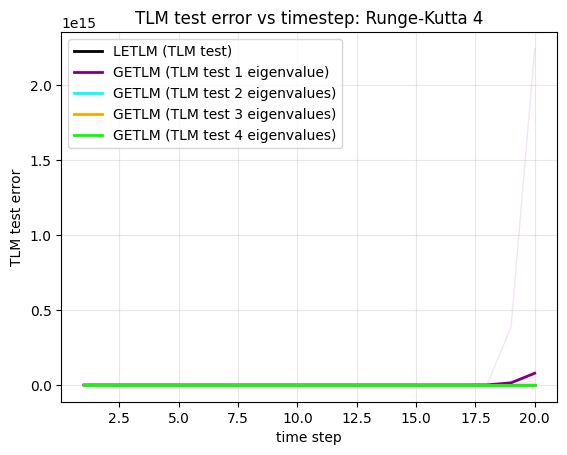

<Figure size 640x480 with 0 Axes>

In [31]:
x_values_norm = np.arange(1,steps+1)


plt.plot(x_values_norm, LETLM_mean, label='LETLM (TLM test)', color='black', linewidth=2)
plt.plot(x_values_norm, GETLM_mean_1, label='GETLM (TLM test 1 eigenvalue)', color='purple', linewidth=2)

plt.plot(x_values_norm, results_LETLM.T, color='black', linewidth=1, alpha = 0.1)
plt.plot(x_values_norm, results_GETLM_1.T, color='purple', linewidth=1, alpha = 0.1)
plt.plot(x_values_norm, results_GETLM_2.T, color='aqua', linewidth=1, alpha = 0.1)
plt.plot(x_values_norm, results_GETLM_3.T, color='orange', linewidth=1, alpha = 0.1)
plt.plot(x_values_norm, results_GETLM_4.T, color='lime', linewidth=1, alpha = 0.1)

plt.plot(x_values_norm, GETLM_mean_2, label='GETLM (TLM test 2 eigenvalues)', color='aqua', linewidth=2)
plt.plot(x_values_norm, GETLM_mean_3, label='GETLM (TLM test 3 eigenvalues)', color='orange', linewidth=2)
plt.plot(x_values_norm, GETLM_mean_4, label='GETLM (TLM test 4 eigenvalues)', color='lime', linewidth=2)

plt.title("TLM test error vs timestep: Runge-Kutta 4")
plt.xlabel("time step")
plt.ylabel("TLM test error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()

/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_66966/1039257069.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  letlm = np.array(LETLM_mean)
/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_66966/1039257069.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  getlm1 = np.array(GETLM_mean_1)
/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_66966/1039257069.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so 

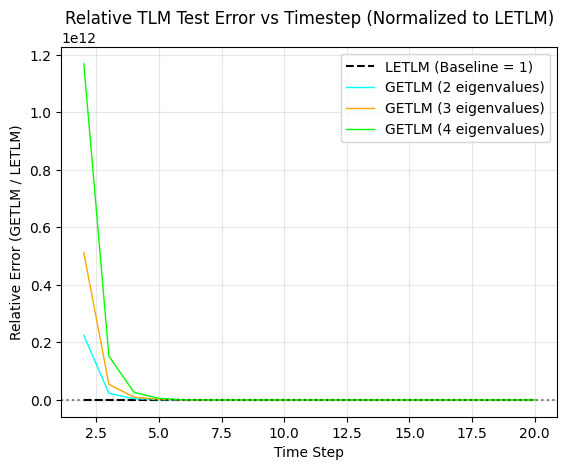

<Figure size 640x480 with 0 Axes>

In [27]:
# 1. Ensure your results are NumPy arrays
letlm = np.array(LETLM_mean)
getlm1 = np.array(GETLM_mean_1)
getlm2 = np.array(GETLM_mean_2)
getlm3 = np.array(GETLM_mean_3)
getlm4 = np.array(GETLM_mean_4)

x_values_norm = np.arange(1, len(letlm) + 1)

# 2. Now you can perform element-wise division
plt.plot(x_values_norm, letlm / letlm, label='LETLM (Baseline = 1)', color='black', linewidth=1.5, linestyle='--')
# plt.plot(x_values_norm, getlm1 / letlm, label='GETLM (1 eigenvalue)', color='purple', linewidth=1)
plt.plot(x_values_norm, getlm2 / letlm, label='GETLM (2 eigenvalues)', color='aqua', linewidth=1)
plt.plot(x_values_norm, getlm3 / letlm, label='GETLM (3 eigenvalues)', color='orange', linewidth=1)
plt.plot(x_values_norm, getlm4 / letlm, label='GETLM (4 eigenvalues)', color='lime', linewidth=1)


plt.axhline(y=1, color='black', linestyle=':', alpha=0.5)

plt.title("Relative TLM Test Error vs Timestep (Normalized to LETLM)")
plt.xlabel("Time Step")
plt.ylabel("Relative Error (GETLM / LETLM)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.clf()

# ... rest of your plot code

In [28]:
# We also need to check if how many times the IETLM is worse than the GIETLM variants
GETLM_1_wins_1 = 0
GETLM_1_wins_5 = 0
GETLM_1_wins_10 = 0
GETLM_1_wins_15 = 0


GETLM_2_wins_1 = 0
GETLM_2_wins_5 = 0
GETLM_2_wins_10 = 0
GETLM_2_wins_15 = 0

GETLM_3_wins_1 = 0
GETLM_3_wins_5 = 0
GETLM_3_wins_10 = 0
GETLM_3_wins_15 = 0

GETLM_4_wins_1 = 0
GETLM_4_wins_5 = 0
GETLM_4_wins_10 = 0
GETLM_4_wins_15 = 0

for i in range(trials):
    letlm_trial = results_LETLM[i,:]
    # print(ietlm_trial.shape)
    GETLM_1_trial = results_GETLM_1[i,:]
    GETLM_2_trial = results_GETLM_2[i,:]
    GETLM_3_trial = results_GETLM_3[i,:]
    GETLM_4_trial = results_GETLM_4[i,:]

    # We see how the model does after 1 time step 
    if GETLM_1_trial[2] <= letlm_trial[2]:
        GETLM_1_wins_1 += 1

    if GETLM_2_trial[2] <= letlm_trial[2]:
        GETLM_2_wins_1 += 1

    if GETLM_3_trial[2] <= letlm_trial[2]:
        GETLM_3_wins_1 += 1

    if GETLM_4_trial[2] <= letlm_trial[2]:
        GETLM_4_wins_1 += 1
    
    # We can now do after 5 time steps

    if GETLM_1_trial[6] <= letlm_trial[6]:
        GETLM_1_wins_5 += 1

    if GETLM_2_trial[6] <= letlm_trial[6]:
        GETLM_2_wins_5 += 1

    if GETLM_3_trial[6] <= letlm_trial[6]:
        GETLM_3_wins_5 += 1

    if GETLM_4_trial[6] <= letlm_trial[6]:
        GETLM_4_wins_5 += 1

    # We can now do after 10 time steps

    if GETLM_1_trial[11] <= letlm_trial[11]:
        GETLM_1_wins_10 += 1

    if GETLM_2_trial[11] <= letlm_trial[11]:
        GETLM_2_wins_10 += 1

    if GETLM_3_trial[11] <= letlm_trial[11]:
        GETLM_3_wins_10 += 1

    if GETLM_4_trial[11] <= letlm_trial[11]:
        GETLM_4_wins_10 += 1

    # We can now do after 15 time steps

    if GETLM_1_trial[16] < letlm_trial[16]:
        GETLM_1_wins_15 += 1

    if GETLM_2_trial[16] <= letlm_trial[16]:
        GETLM_2_wins_15 += 1

    if GETLM_3_trial[16] <= letlm_trial[16]:
        GETLM_3_wins_15 += 1

    if GETLM_4_trial[16] <= letlm_trial[16]:
        GETLM_4_wins_15 += 1

print("GETLM (1) wins after 1 step:",GETLM_1_wins_1)
print("GETLM (2) wins after 1 step:",GETLM_2_wins_1)
print("GETLM (3) wins after 1 step:",GETLM_3_wins_1)
print("GETLM (4) wins after 1 step:",GETLM_4_wins_1)

print("GETLM (1) wins after 5 steps:",GETLM_1_wins_5)
print("GETLM (2) wins after 5 steps:",GETLM_2_wins_5)
print("GETLM (3) wins after 5 steps:",GETLM_3_wins_5)
print("GETLM (4) wins after 5 steps:",GETLM_4_wins_5)

print("GETLM (1) wins after 10 steps:",GETLM_1_wins_10)
print("GETLM (2) wins after 10 steps:",GETLM_2_wins_10)
print("GETLM (3) wins after 10 steps:",GETLM_3_wins_10)
print("GETLM (4) wins after 10 steps:",GETLM_4_wins_10)


print("GETLM (1) wins after 15 steps:",GETLM_1_wins_15)
print("GETLM (2) wins after 15 steps:",GETLM_2_wins_15)
print("GETLM (3) wins after 15 steps:",GETLM_3_wins_15)
print("GETLM (4) wins after 15 steps:",GETLM_4_wins_15)


GETLM (1) wins after 1 step: 17
GETLM (2) wins after 1 step: 0
GETLM (3) wins after 1 step: 0
GETLM (4) wins after 1 step: 0
GETLM (1) wins after 5 steps: 15
GETLM (2) wins after 5 steps: 0
GETLM (3) wins after 5 steps: 0
GETLM (4) wins after 5 steps: 0
GETLM (1) wins after 10 steps: 0
GETLM (2) wins after 10 steps: 0
GETLM (3) wins after 10 steps: 0
GETLM (4) wins after 10 steps: 0
GETLM (1) wins after 15 steps: 0
GETLM (2) wins after 15 steps: 0
GETLM (3) wins after 15 steps: 0
GETLM (4) wins after 15 steps: 0
